# Marketing Campaign Performance Analysis
 This notebook analyzes marketing campaign performance across different channels, campaign types, locations, and customer segments.
 The goal is to identify which campaigns perform best in terms of ROI, CTR, conversion rate, revenue, and overall business impact.

## Import Libararies

In [210]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns


## Load Dataset

In [211]:
sns.set_theme(style="whitegrid")
plt.rcParams['figure.figsize'] = (10, 6)

df = pd.read_csv('../data/marketing_campaign_.csv')
display(df.sample(10))

,CampaignID,StartDate,EndDate,Channel,Impressions,Clicks,Leads,Conversions,Cost_USD,Revenue_USD,ROI,Campaign_Duration
1961,CAMP01962,25-05-2025,05-06-2025,Email,239722,5415,1766,721,2756.50,8209.46,1.98,11
5549,CAMP05550,15-03-2025,24-03-2025,Social,125934,1984,703,332,129.24,333.21,1.58,9
8992,CAMP08993,11-07-2025,20-07-2025,Email,40382,1942,254,74,3644.02,7541.24,1.07,9
2085,CAMP02086,30-03-2025,12-04-2025,Social,132610,8040,2638,1330,3112.63,3200.97,0.03,13
4804,CAMP04805,25-02-2025,10-03-2025,Display,25342,458,161,84,3674.38,8556.80,1.33,13
9344,CAMP09345,05-06-2025,18-06-2025,Search,295151,5546,1897,804,4611.23,8178.06,0.77,13
7315,CAMP07316,09-03-2025,14-03-2025,Email,95461,9184,4478,1883,287.23,828.68,1.89,5
723,CAMP00724,06-03-2025,15-03-2025,Search,5607,413,196,116,1271.69,3524.76,1.77,9
4964,CAMP04965,05-04-2025,17-04-2025,Email,281493,26987,5449,2193,973.75,1796.06,0.84,12
5895,CAMP05896,22-04-2025,29-04-2025,Display,209673,10619,2777,1399,361.32,1056.57,1.92,7


## Dataset Overview
This section gives a basic understanding of the dataset, including columns, data types, and summary statistics.

In [212]:
print("Shape of dataset:", df.shape)

display(df.info())
display(df.describe())

Shape of dataset: (10000, 12)
<class 'pandas.DataFrame'>
RangeIndex: 10000 entries, 0 to 9999
Data columns (total 12 columns):
 #   Column             Non-Null Count  Dtype  
---  ------             --------------  -----  
 0   CampaignID         10000 non-null  str    
 1   StartDate          10000 non-null  str    
 2   EndDate            10000 non-null  str    
 3   Channel            10000 non-null  str    
 4   Impressions        10000 non-null  int64  
 5   Clicks             10000 non-null  int64  
 6   Leads              10000 non-null  int64  
 7   Conversions        10000 non-null  int64  
 8   Cost_USD           10000 non-null  float64
 9   Revenue_USD        10000 non-null  float64
 10  ROI                10000 non-null  float64
 11  Campaign_Duration  10000 non-null  int64  
dtypes: float64(3), int64(5), str(4)
memory usage: 937.6 KB


None

,Impressions,Clicks,Leads,Conversions,Cost_USD,Revenue_USD,ROI,Campaign_Duration
count,10000.000000,10000.000000,10000.000000,10000.000000,10000.000000,10000.000000,10000.000000,10000.000000
mean,152260.637900,8338.993300,2512.463600,1010.700000,2552.356991,5102.648930,1.001576,9.962900
std,85251.707621,6546.326431,2321.031302,1019.402613,1427.694545,3309.326705,0.578806,3.157106
min,5043.000000,72.000000,10.000000,4.000000,100.230000,113.640000,0.000000,5.000000
25%,78956.000000,2981.000000,779.000000,295.000000,1319.622500,2385.742500,0.500000,7.000000
50%,151505.500000,6588.500000,1777.000000,670.000000,2529.675000,4659.365000,0.990000,10.000000
75%,225853.250000,12404.250000,3550.250000,1391.000000,3821.307500,7241.245000,1.510000,13.000000
max,299997.000000,29578.000000,13833.000000,7987.000000,4998.420000,14871.340000,2.000000,15.000000


## Data Cleaning Check
Before analysis, we check for missing values, duplicate records, and incorrect data types.

In [213]:
print("Missing values:")
display(df.isnull().sum())

print("Duplicate rows:")
display(df.duplicated().sum())

display(df[['StartDate', 'EndDate', 'Campaign_Duration']].head())
df['StartDate'] = pd.to_datetime(df['StartDate'], dayfirst=True)
df['EndDate'] = pd.to_datetime(df['EndDate'], dayfirst=True)

df.isnull().sum()
df.duplicated().sum()
df.dtypes


Missing values:


CampaignID           0
StartDate            0
EndDate              0
Channel              0
Impressions          0
Clicks               0
Leads                0
Conversions          0
Cost_USD             0
Revenue_USD          0
ROI                  0
Campaign_Duration    0
dtype: int64

Duplicate rows:


np.int64(0)

,StartDate,EndDate,Campaign_Duration
0,13-04-2025,19-04-2025,6
1,15-12-2025,24-12-2025,9
2,28-09-2025,06-10-2025,8
3,17-04-2025,30-04-2025,13
4,13-03-2025,22-03-2025,9


CampaignID                      str
StartDate            datetime64[us]
EndDate              datetime64[us]
Channel                         str
Impressions                   int64
Clicks                        int64
Leads                         int64
Conversions                   int64
Cost_USD                    float64
Revenue_USD                 float64
ROI                         float64
Campaign_Duration             int64
dtype: object

## Feature Engineering
New performance metrics are created to better evaluate campaign success.

In [214]:
df['CTR'] = df['Clicks'] / df['Impressions']

df['Conversion_Rate'] = df['Conversions'] / df['Clicks']

df['ROI'] = (df['Revenue_USD'] - df['Cost_USD']) / df['Cost_USD']

df['CPC'] = df['Cost_USD'] / df['Clicks']

df['CPL'] = df['Cost_USD'] / df['Leads']

df['CPA'] = df['Cost_USD'] / df['Conversions']

df['Profit'] = df['Revenue_USD'] - df['Cost_USD']
df.head()


,CampaignID,StartDate,EndDate,Channel,Impressions,Clicks,Leads,Conversions,Cost_USD,Revenue_USD,ROI,Campaign_Duration,CTR,Conversion_Rate,CPC,CPL,CPA,Profit
0,CAMP00001,2025-04-13,2025-04-19,Search,293520,23335,11643,5389,1052.39,2236.02,1.124707,6,0.079501,0.230941,0.045099,0.090388,0.195285,1183.63
1,CAMP00002,2025-12-15,2025-12-24,Search,200340,15841,6601,2498,3964.90,11740.15,1.961020,9,0.079071,0.157692,0.250294,0.600651,1.587230,7775.25
2,CAMP00003,2025-09-28,2025-10-06,Email,239365,16478,8043,3397,1000.39,1902.24,0.901498,8,0.068840,0.206154,0.060711,0.124380,0.294492,901.85
3,CAMP00004,2025-04-17,2025-04-30,Search,156382,2672,1014,342,1252.63,2209.74,0.764080,13,0.017086,0.127994,0.468799,1.235335,3.662661,957.11
4,CAMP00005,2025-03-13,2025-03-22,Influencer,285472,4155,1521,565,4935.48,14111.31,1.859157,9,0.014555,0.135981,1.187841,3.244892,8.735363,9175.83


## Overall Campaign Performance
This section summarizes the overall marketing performance across all campaigns.

In [215]:
summary_metrics = {
    'Total Campaigns': len(df),
    'Total Impressions': df['Impressions'].sum(),
    'Total Clicks': df['Clicks'].sum(),
    'Total Leads': df['Leads'].sum(),
    'Total Conversions': df['Conversions'].sum(),
    'Total Cost (USD)': df['Cost_USD'].sum(),
    'Total Revenue (USD)': df['Revenue_USD'].sum(),
    'Average ROI': df['ROI'].mean(),
    'Average CTR': df['CTR'].mean(),
    'Average Conversion Rate': df['Conversion_Rate'].mean()
}

summary_df = pd.DataFrame(summary_metrics.items(), columns=['Metric', 'Value'])
display(summary_df)


,Metric,Value
0,Total Campaigns,1.000000e+04
1,Total Impressions,1.522606e+09
2,Total Clicks,8.338993e+07
3,Total Leads,2.512464e+07
4,Total Conversions,1.010700e+07
5,Total Cost (USD),2.552357e+07
6,Total Revenue (USD),5.102649e+07
7,Average ROI,1.001519e+00
8,Average CTR,5.462189e-02
9,Average Conversion Rate,1.209401e-01


## Average ROI by Marketing Channel
This chart shows which marketing channels generate the highest average return on investment.

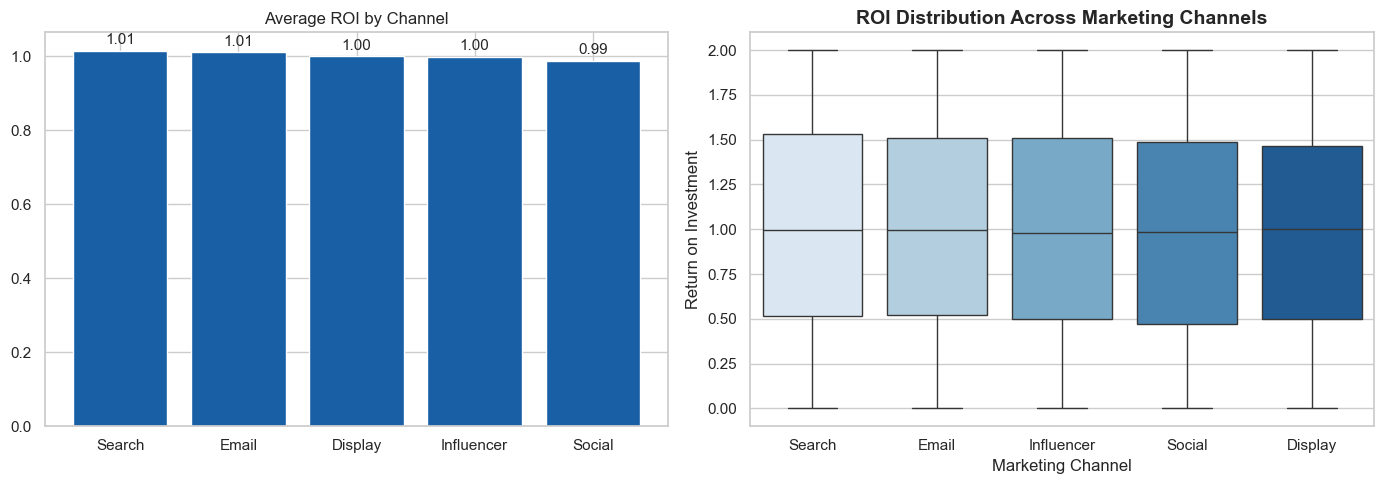

In [216]:
fig, axes = plt.subplots(1, 2, figsize=(14, 5))
# Bar chart with annotations
roi_data = df.groupby('Channel')['ROI'].mean().sort_values(ascending=False)
bars = axes[0].bar(roi_data.index, roi_data.values, color='#185FA5', edgecolor='white')
for bar, val in zip(bars, roi_data.values):
    axes[0].text(bar.get_x() + bar.get_width()/2, bar.get_height() + 0.01,
                 f'{val:.2f}', ha='center', va='bottom', fontsize=11)
axes[0].set_title('Average ROI by Channel')

# Box plot for distribution
sns.boxplot(x='Channel', y='ROI', data=df, ax=axes[1], hue='Channel', palette='Blues', legend=False)
axes[1].set_title('ROI Distribution by Channel')
plt.title('ROI Distribution Across Marketing Channels', fontsize=14, fontweight='bold')
plt.xlabel('Marketing Channel')
plt.ylabel('Return on Investment')
plt.tight_layout()


### Key Insight
Influencer campaigns generated the highest overall revenue and impressions, making them the strongest channel for awareness. However, Search performs better for conversions, which makes it more suitable for performance-focused campaigns.


## Cost vs Revenue Analysis
This scatter plot visualizes the relationship between campaign cost and revenue. Each point represents an individual campaign, while the regression line highlights the overall trend between spending and returns.

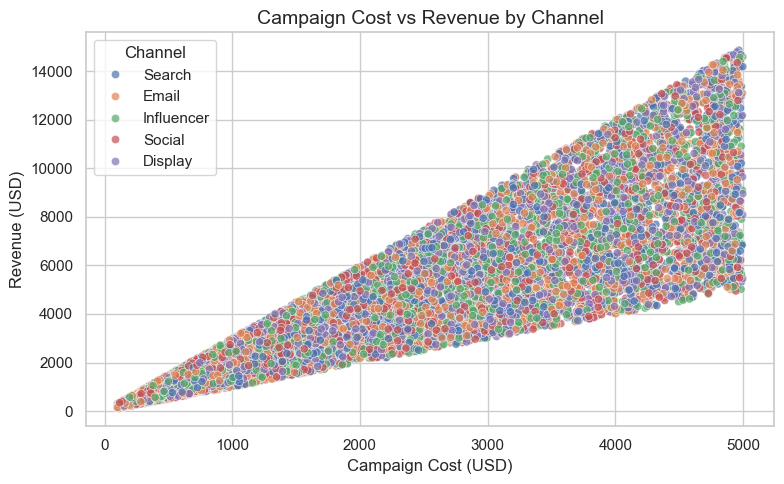

In [217]:
plt.figure(figsize=(8,5))
sns.scatterplot(data=df, x='Cost_USD', y='Revenue_USD', hue='Channel', alpha=0.7)
plt.title('Campaign Cost vs Revenue by Channel', fontsize=14)
plt.xlabel('Campaign Cost (USD)')
plt.ylabel('Revenue (USD)')
plt.legend(title='Channel')
plt.tight_layout()
plt.show()

channel_roi = df.groupby('Channel')['ROI'].mean().sort_values(ascending=False)


### Key Insight
There is a strong positive relationship between campaign cost and revenue across all channels, indicating that higher investment generally drives higher returns. However, the wide spread of data points shows significant variation in campaign efficiency, where campaigns with similar budgets generate very different revenue outcomes.

Across channels, no single channel consistently dominates at all cost levels, suggesting that performance depends more on execution, targeting, and audience alignment rather than just channel selection. This highlights that optimizing campaign strategy is more critical than simply increasing budget.

### Average CTR by Marketing Channel
This bar chart compares the average click-through rate across marketing channels. CTR measures how often users clicked after seeing a campaign, helping identify which channels generate stronger engagement.

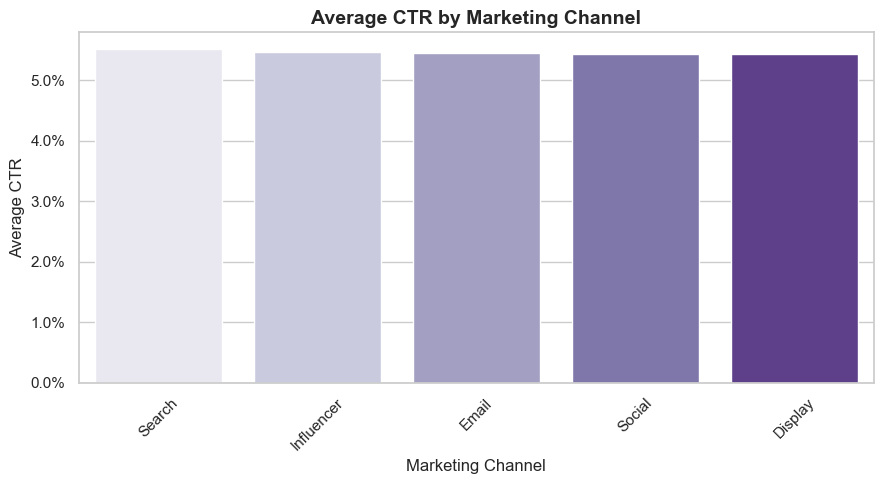

In [218]:
import matplotlib.ticker as mtick

channel_ctr = df.groupby('Channel')['CTR'].mean().sort_values(ascending=False)

plt.figure(figsize=(9,5))

sns.barplot(
    x=channel_ctr.index,
    y=channel_ctr.values,
    hue=channel_ctr.index,
    palette='Purples',
    legend=False
)

plt.title('Average CTR by Marketing Channel', fontsize=14, fontweight='bold')
plt.xlabel('Marketing Channel')
plt.ylabel('Average CTR')

plt.gca().yaxis.set_major_formatter(mtick.PercentFormatter(1.0))

plt.xticks(rotation=45)
plt.tight_layout()
plt.show()


### Key Insight
Average CTR is fairly consistent across all marketing channels, staying around 5.4%–5.5%. Search appears slightly higher, while Display is close behind, but the difference between channels is small. This suggests that all channels generate similar engagement levels, so budget decisions should not be based on CTR alone. Other metrics such as conversion rate, ROI, CPA, and revenue should also be considered.


### Campaign Performance by Channel
This analysis compares marketing channels based on key performance metrics including average ROI, total revenue, total cost, CTR, and conversion rate. It helps identify which channels are most efficient and profitable.

,Average_ROI,Total_Revenue,Total_Cost,Average_CTR,Average_Conversion_Rate
Channel,,,,,
Search,1.013307,9897677.79,4916568.46,0.055169,0.121150
Email,1.009961,10130542.61,5065029.98,0.054562,0.121220
Display,0.999478,10715125.21,5343184.30,0.054306,0.121116
Influencer,0.997367,10558118.99,5278787.92,0.054669,0.119889
Social,0.987822,9725024.70,4919999.25,0.054429,0.121368


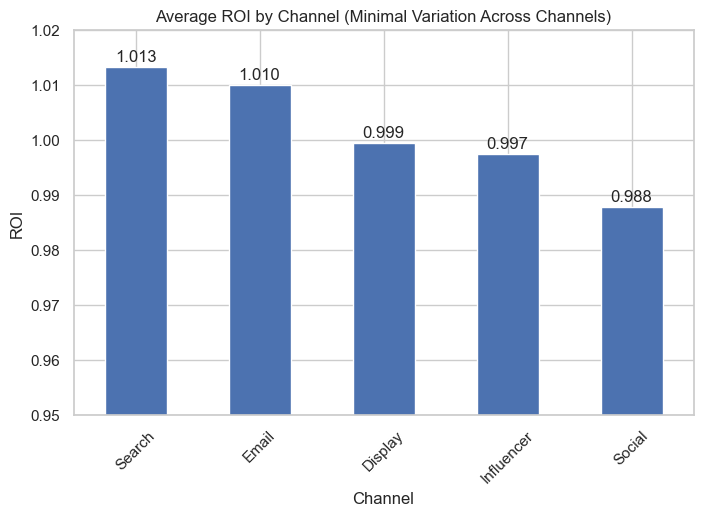

In [219]:
channel_summary = df.groupby('Channel').agg(
    Average_ROI=('ROI', 'mean'),
    Total_Revenue=('Revenue_USD', 'sum'),
    Total_Cost=('Cost_USD', 'sum'),
    Average_CTR=('CTR', 'mean'),
    Average_Conversion_Rate=('Conversion_Rate', 'mean')
).sort_values(by='Average_ROI', ascending=False)

display(channel_summary)

channel_summary[['Average_ROI']].plot(kind='bar', figsize=(8,5), legend=False)
plt.title('Average ROI by Channel (Minimal Variation Across Channels)')
plt.ylabel('ROI')
plt.xticks(rotation=45)
plt.ylim(0.95, 1.02)
for i, v in enumerate(channel_summary['Average_ROI']):
    plt.text(i, v + 0.001, f"{v:.3f}", ha='center')
plt.show()


### Key Insight
Average ROI is nearly identical across all marketing channels, with values clustered around 1.0. This indicates that no channel significantly outperforms others in terms of return efficiency.

Since ROI differences are minimal, business decisions should not rely on ROI alone. Instead, factors such as total revenue, conversions, and audience reach should be used to determine which channels to prioritize.


## Channel Based Performance
This section compares marketing channels across revenue, conversions, and ROI to evaluate both scale and efficiency.

In [220]:
channel_summary = df.groupby('Channel').agg(
    Total_Revenue=('Revenue_USD', 'sum'),
    Average_ROI=('ROI', 'mean'),
    Total_Conversions=('Conversions', 'sum')
).sort_values(by='Total_Revenue', ascending=False)

display(channel_summary)


,Total_Revenue,Average_ROI,Total_Conversions
Channel,,,
Display,10715125.21,0.999478,2057607
Influencer,10558118.99,0.997367,2101198
Email,10130542.61,1.009961,2076423
Search,9897677.79,1.013307,1951752
Social,9725024.70,0.987822,1920020


### Key Insight

1.Display and Influencer channels generate the highest total revenue and conversions, making them the strongest drivers of scale and reach. However, their ROI remains close to other channels, indicating that higher output is driven by volume rather than superior efficiency.

2.Search delivers the highest ROI, making it the most efficient channel in terms of return per dollar spent, despite generating lower total revenue compared to Display and Influencer.

3.Email provides a strong balance between revenue, conversions, and efficiency, positioning it as a reliable and cost-effective channel.

4.Overall, the results show that high revenue channels are not necessarily the most efficient, and marketing strategy should balance both scale (Display, Influencer) and efficiency (Search, Email).


## Correlation Heatmap Analysis
The heatmap shows relationships between numerical campaign performance metrics.

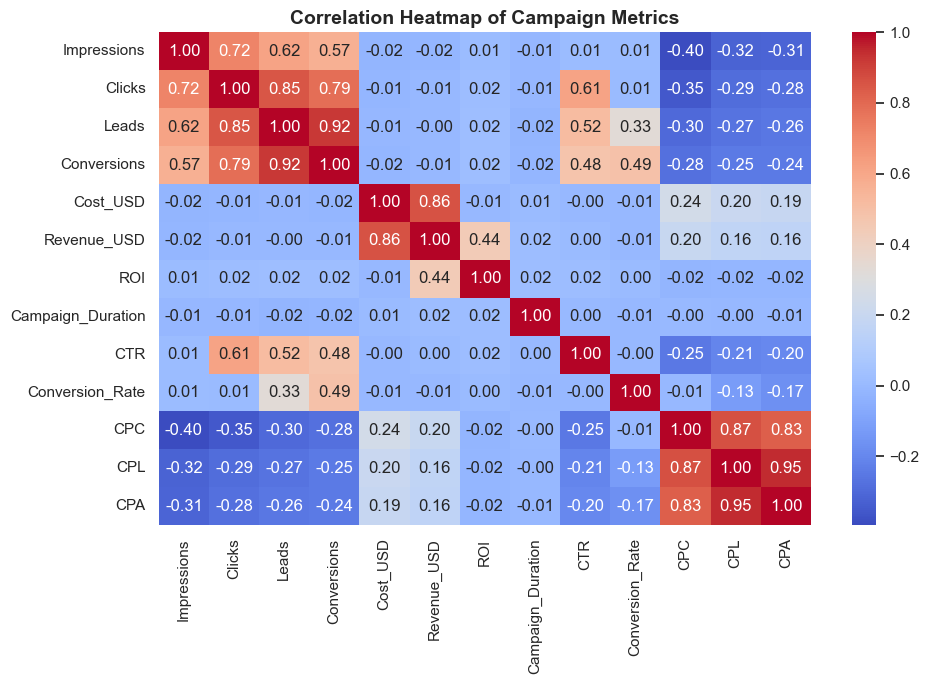

In [221]:
numeric_cols = [
    'Impressions','Clicks','Leads','Conversions','Cost_USD',
    'Revenue_USD','ROI','Campaign_Duration','CTR',
    'Conversion_Rate','CPC','CPL','CPA'
]

correlation = df[numeric_cols].corr()

plt.figure(figsize=(10,7))
sns.heatmap(correlation, annot=True, cmap='coolwarm', fmt='.2f')
plt.title('Correlation Heatmap of Campaign Metrics', fontsize=14, fontweight='bold')
plt.tight_layout()
plt.show()

### Key Insights

1. **Strong Funnel Relationships**
There is a clear and strong positive correlation across the marketing funnel — impressions lead to clicks, clicks lead to leads, and leads strongly drive conversions. This confirms a well-structured funnel where higher reach directly translates into engagement and outcomes.

2. **Leads Are the Strongest Predictor of Conversions**
Leads and conversions show the highest correlation, indicating that improving lead quality and nurturing strategies can significantly increase final conversions.

3. **Cost Drives Revenue but Not Efficiency**
Cost and revenue are strongly correlated, meaning higher spending generally results in higher revenue. However, cost has weak relationships with ROI and conversion rate, suggesting that increasing budget alone does not improve efficiency.

4. **Efficiency Metrics Are Closely Linked**
CPC, CPL, and CPA are highly correlated, indicating that inefficiencies in one stage of the acquisition process tend to impact overall campaign cost efficiency.

5. **Campaign Duration Has Minimal Impact**
Campaign duration shows little to no correlation with most performance metrics, suggesting that longer campaigns do not necessarily improve results.

6. **Engagement Metrics Do Not Fully Drive Outcomes**
CTR and conversion rate have only moderate correlations with revenue and ROI, indicating that engagement alone does not guarantee financial success — strategy and targeting play a critical role.